# 📘 Jupyter Notebook: L1 и L2 регуляризация (Lasso и Ridge)

---

## 🧠 1. Введение

Линейная регрессия пытается найти коэффициенты $w$, которые минимизируют ошибку:

$$
\text{MSE} = \frac{1}{n} \sum (y_i - \hat{y}_i)^2
$$

Но есть проблема:
👉 модель может **переобучаться (overfitting)**, особенно если признаков много.

Чтобы бороться с этим, используют **регуляризацию**.


## 🎯 2. Идея регуляризации

Регуляризация добавляет штраф за "слишком большие" коэффициенты:

$$
\text{Loss} = \text{MSE} + \text{Regularization term}
$$

Это делает модель:

* проще
* устойчивее
* менее склонной к переобучению




## 🔵 3. L2 регуляризация (Ridge)

### Формула:

$$
\text{Loss} = \frac{1}{n} \sum (y_i - \hat{y}_i)^2 + \lambda \sum w_j^2
$$

👉 добавляется **квадрат коэффициентов**

### Интуиция:

* большие коэффициенты сильно штрафуются
* модель "размазывает" важность между признаками
* **коэффициенты не становятся равны нулю**


## 🔴 4. L1 регуляризация (Lasso)

### Формула:

$$
\text{Loss} = \frac{1}{n} \sum (y_i - \hat{y}_i)^2 + \lambda \sum |w_j|
$$

👉 добавляется **модуль коэффициентов**

### Интуиция:

* некоторые коэффициенты становятся **точно равны нулю**
* происходит **отбор признаков (feature selection)**



## ⚖️ 5. Сравнение Ridge vs Lasso

| Свойство              | Ridge (L2)         | Lasso (L1)           |
| --------------------- | ------------------ | -------------------- |
| Обнуляет коэффициенты | ❌ Нет              | ✅ Да                 |
| Устойчивость          | Высокая            | Средняя              |
| Отбор признаков       | ❌ Нет              | ✅ Да                 |
| Используется когда    | признаки важны все | есть лишние признаки |



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score
from sklearn.linear_model import ElasticNet

In [ ]:
np.random.seed(42)

n_samples = 100
n_features = 10

X = np.random.randn(n_samples, n_features)

true_weights = np.array([5, 3, 0, 2, 1, 0, 0, 0, 2, 4])
y = X @ true_weights + np.random.randn(n_samples) * 0.5

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("RMSE (Linear):", root_mean_squared_error(y_test, y_pred))
print(r2_score(y_test, y_pred))
print("Weights:", lr.coef_)

RMSE (Linear): 0.5432570719651543
0.9914391900698167
Weights: [ 4.98033537  2.98788853  0.00668466  2.03011859  0.93981154  0.00772131
 -0.13313811  0.03863468  2.01615243  3.99974202]


In [ ]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

print("RMSE (Ridge):", root_mean_squared_error(y_test, y_pred_ridge))
print(r2_score(y_test, y_pred_ridge))
print("Weights:", ridge.coef_)

MSE (Ridge): 0.5051527995107233
0.9925979910476379
Weights: [ 4.90311492  2.92836074  0.02279581  2.00957879  0.9361352   0.00862183
 -0.13366913  0.04424154  1.99625099  3.93094438]


In [ ]:
lasso = Lasso(alpha=0.5)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

print("RMSE (Lasso):", root_mean_squared_error(y_test, y_pred_lasso))
print(r2_score(y_test, y_pred_lasso))
print("Weights:", lasso.coef_)

MSE (Lasso): 0.4828396207557233
0.9932374595167007
Weights: [ 4.92864714  2.92318122  0.          1.97006973  0.907176    0.
 -0.07126152  0.          1.97648849  3.93196868]


In [ ]:
from sklearn.model_selection import GridSearchCV

lasso = Lasso(alpha=0.2)

lasso_gs = GridSearchCV(
    lasso,
    param_grid={
        'alpha': [0.01, 0.05, 0.1, 0.2]
    },
    cv=5, scoring='neg_root_mean_squared_error'
)

lasso_gs.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=Lasso(alpha=0.2),
             param_grid={'alpha': [0.01, 0.05, 0.1, 0.2]},
             scoring='neg_root_mean_squared_error')

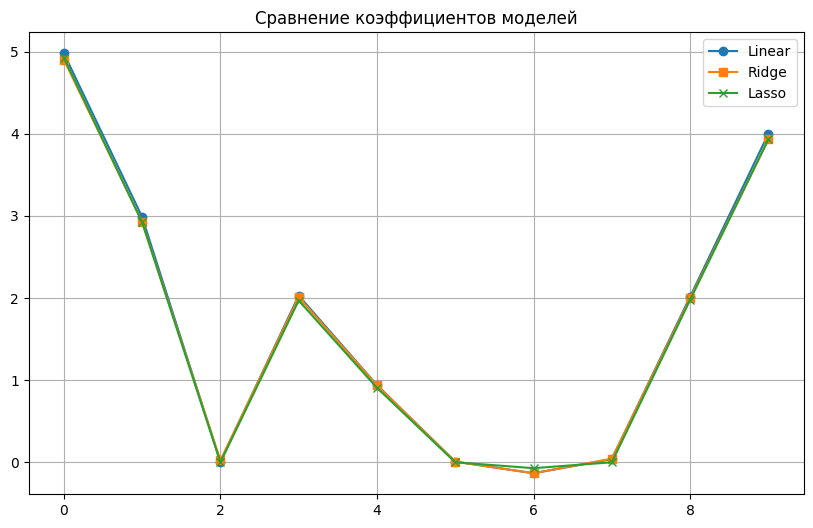

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(lr.coef_, 'o-', label="Linear")
plt.plot(ridge.coef_, 's-', label="Ridge")
plt.plot(lasso.coef_, 'x-', label="Lasso")

plt.title("Сравнение коэффициентов моделей")
plt.legend()
plt.grid()
plt.show()

In [ ]:
alphas = np.logspace(-3, 10, 50)

ridge_weights = []
lasso_weights = []

for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train, y_train)
    ridge_weights.append(ridge.coef_)
    
    lasso = Lasso(alpha=a)
    lasso.fit(X_train, y_train)
    lasso_weights.append(lasso.coef_)

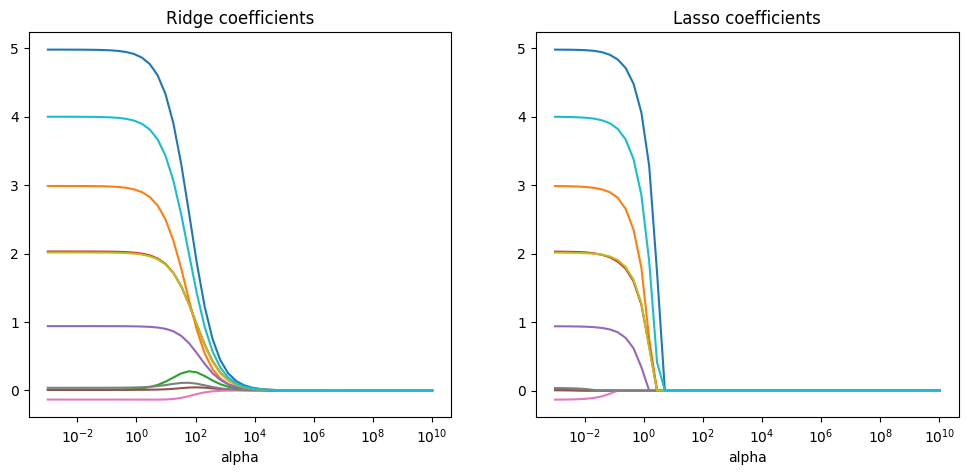

In [ ]:
ridge_weights = np.array(ridge_weights)
lasso_weights = np.array(lasso_weights)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(alphas, ridge_weights)
plt.xscale("log")
plt.title("Ridge coefficients")
plt.xlabel("alpha")

plt.subplot(1,2,2)
plt.plot(alphas, lasso_weights)
plt.xscale("log")
plt.title("Lasso coefficients")
plt.xlabel("alpha")

plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

np.logspace(-3, 2, 50)

param_grid = {
    'alpha': np.logspace(-3, 2, 50)
}

lasso_cv = GridSearchCV(Lasso(), param_grid, cv=5)
lasso_cv.fit(X_train, y_train)

lasso_best = lasso_cv.best_estimator_
y_pred_lasso_cv = lasso_best.predict(X_test)


## 🧠 15. Важные выводы

👉 Ridge:

* уменьшает коэффициенты
* не зануляет их
* хорош при коррелированных признаках

👉 Lasso:

* зануляет часть коэффициентов
* делает автоматический feature selection

👉 Параметр `alpha`:

* маленький → почти нет регуляризации
* большой → сильное упрощение модели

# 🟣 17. ElasticNet — комбинация L1 и L2

ElasticNet объединяет оба штрафа:

$$
\text{Loss} = \frac{1}{n}\sum (y_i - \hat{y}_i)^2 + \lambda_1 \sum |w_j| + \lambda_2 \sum w_j^2
$$

В реализации используется параметр:

* `alpha` — общая сила регуляризации
* `l1_ratio` — баланс между L1 и L2

$$
l1_{ratio} = 0 \Rightarrow \text{Ridge}
$$
$$
l1_{ratio} = 1 \Rightarrow \text{Lasso}
$$

In [ ]:
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic.fit(X_train, y_train)

y_pred_elastic = elastic.predict(X_test)

print("MSE (ElasticNet):", mean_squared_error(y_test, y_pred_elastic))
print("Weights:", elastic.coef_)

MSE (ElasticNet): 0.27157221876265414
Weights: [ 4.64115094  2.70437334  0.03428408  1.89475758  0.89418024  0.
 -0.07495488  0.          1.89854747  3.67747403]


In [ ]:
from sklearn.model_selection import GridSearchCV

np.logspace(-3, 2, 50)

param_grid = {
    'alpha': np.logspace(-3, 2, 50),
    'l1_ratio': [0.1, 0.5, 0.9]
}

lasso_cv = GridSearchCV(ElasticNet(), param_grid, cv=5)
lasso_cv.fit(X_train, y_train)

lasso_best = lasso_cv.best_estimator_
y_pred_lasso_cv = lasso_best.predict(X_test)

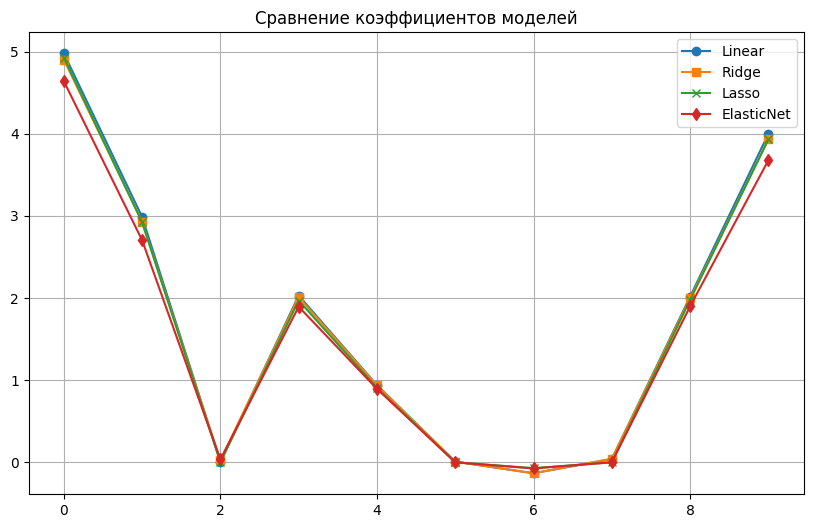

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(lr.coef_, 'o-', label="Linear")
plt.plot(ridge.coef_, 's-', label="Ridge")
plt.plot(lasso.coef_, 'x-', label="Lasso")
plt.plot(elastic.coef_, 'd-', label="ElasticNet")

plt.title("Сравнение коэффициентов моделей")
plt.legend()
plt.grid()
plt.show()

c:\Users\raven\Projects\tutor\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.457e+02, tolerance: 2.708e-01 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


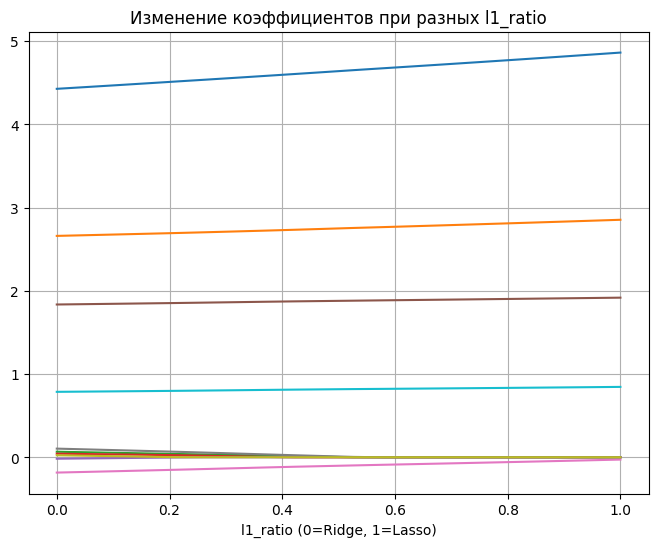

In [ ]:
ratios = np.linspace(0, 1, 20)

elastic_weights = []

for r in ratios:
    model = ElasticNet(alpha=0.1, l1_ratio=r)
    model.fit(X_train, y_train)
    elastic_weights.append(model.coef_)

elastic_weights = np.array(elastic_weights)

plt.figure(figsize=(8,6))
plt.plot(ratios, elastic_weights)
plt.title("Изменение коэффициентов при разных l1_ratio")
plt.xlabel("l1_ratio (0=Ridge, 1=Lasso)")
plt.grid()
plt.show()

In [ ]:
w1 = np.linspace(-3, 3, 200)
w2 = np.linspace(-3, 3, 200)

W1, W2 = np.meshgrid(w1, w2)

# простая квадратичная ошибка
Z = W1**2 + 2*W2**2

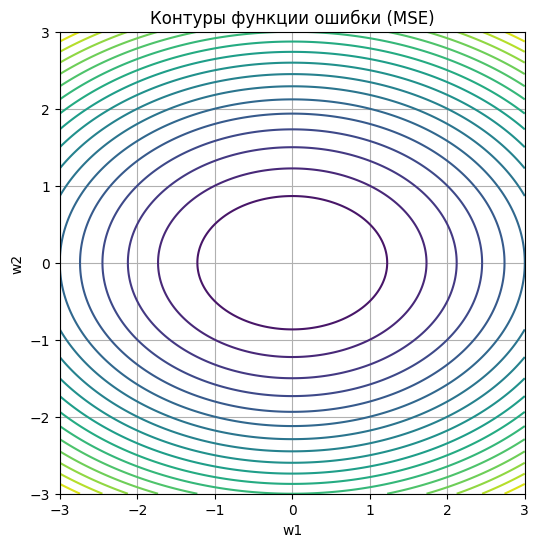

In [ ]:
plt.figure(figsize=(6,6))
plt.contour(W1, W2, Z, levels=20)
plt.title("Контуры функции ошибки (MSE)")
plt.xlabel("w1")
plt.ylabel("w2")
plt.grid()
plt.show()

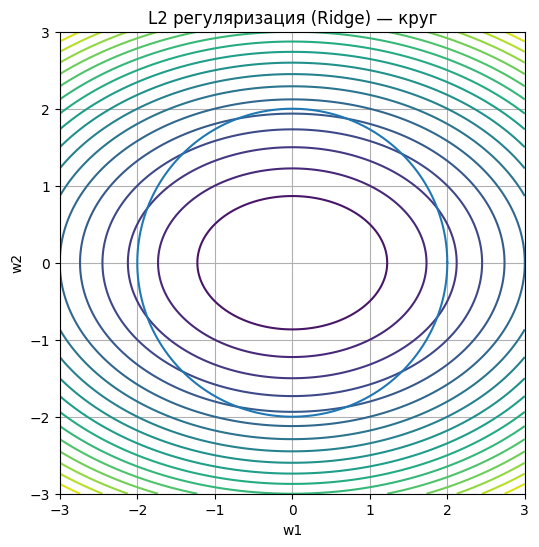

In [ ]:
theta = np.linspace(0, 2*np.pi, 200)
r = 2

x_l2 = r * np.cos(theta)
y_l2 = r * np.sin(theta)

plt.figure(figsize=(6,6))
plt.contour(W1, W2, Z, levels=20)
plt.plot(x_l2, y_l2)

plt.title("L2 регуляризация (Ridge) — круг")
plt.xlabel("w1")
plt.ylabel("w2")
plt.grid()
plt.show()

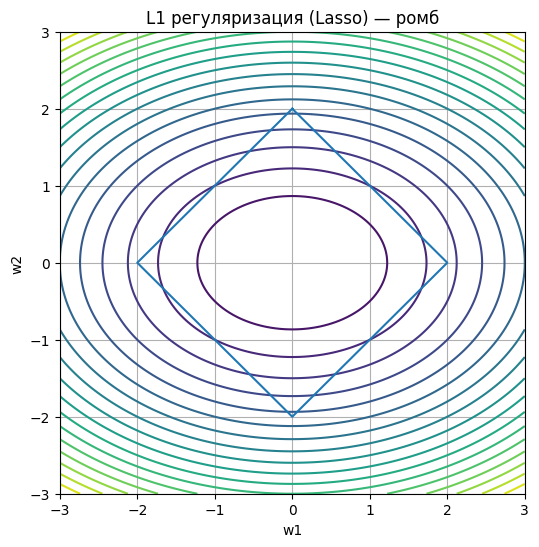

In [ ]:
r = 2

x_l1 = np.array([0, r, 0, -r, 0])
y_l1 = np.array([r, 0, -r, 0, r])

plt.figure(figsize=(6,6))
plt.contour(W1, W2, Z, levels=20)
plt.plot(x_l1, y_l1)

plt.title("L1 регуляризация (Lasso) — ромб")
plt.xlabel("w1")
plt.ylabel("w2")
plt.grid()
plt.show()

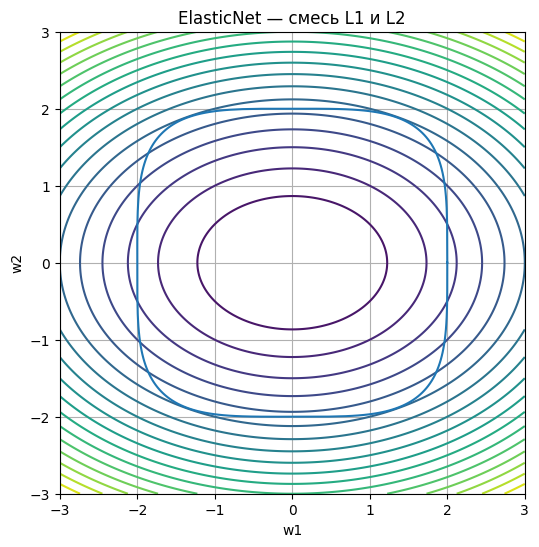

In [ ]:
r = 2

# смешанная форма
x_mix = []
y_mix = []

theta = np.linspace(0, 2*np.pi, 200)

for t in theta:
    x = np.sign(np.cos(t)) * abs(np.cos(t))**0.5
    y = np.sign(np.sin(t)) * abs(np.sin(t))**0.5
    x_mix.append(x * r)
    y_mix.append(y * r)

plt.figure(figsize=(6,6))
plt.contour(W1, W2, Z, levels=20)
plt.plot(x_mix, y_mix)

plt.title("ElasticNet — смесь L1 и L2")
plt.xlabel("w1")
plt.ylabel("w2")
plt.grid()
plt.show()

**Геометрическая идея:**

* Ridge → круг → коэффициенты редко нулевые
* Lasso → ромб → вершины на осях → зануление весов
* ElasticNet → гибрид → баланс между ними